# **CUDA Programming on NVIDIA GPUs**

# **Practical 4**



In [19]:
!nvidia-smi

Wed Jan 28 15:37:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
!wget https://people.maths.ox.ac.uk/gilesm/cuda/headers/helper_cuda.h
!wget https://people.maths.ox.ac.uk/gilesm/cuda/headers/helper_string.h


--2026-01-28 15:37:21--  https://people.maths.ox.ac.uk/gilesm/cuda/headers/helper_cuda.h
Resolving people.maths.ox.ac.uk (people.maths.ox.ac.uk)... 129.67.184.129, 2001:630:441:201::8143:b881
Connecting to people.maths.ox.ac.uk (people.maths.ox.ac.uk)|129.67.184.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27832 (27K) [text/x-chdr]
Saving to: ‘helper_cuda.h.1’

helper_cuda.h.1     100%[===================>]  27.18K   159KB/s    in 0.2s    

2026-01-28 15:37:22 (159 KB/s) - ‘helper_cuda.h.1’ saved [27832/27832]

--2026-01-28 15:37:22--  https://people.maths.ox.ac.uk/gilesm/cuda/headers/helper_string.h
Resolving people.maths.ox.ac.uk (people.maths.ox.ac.uk)... 129.67.184.129, 2001:630:441:201::8143:b881
Connecting to people.maths.ox.ac.uk (people.maths.ox.ac.uk)|129.67.184.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14875 (15K) [text/x-chdr]
Saving to: ‘helper_string.h.1’

helper_string.h.1   100%[===================>]  1

# Question 4

Let's compile and run the executable reduction, and check that it gets the correct result.

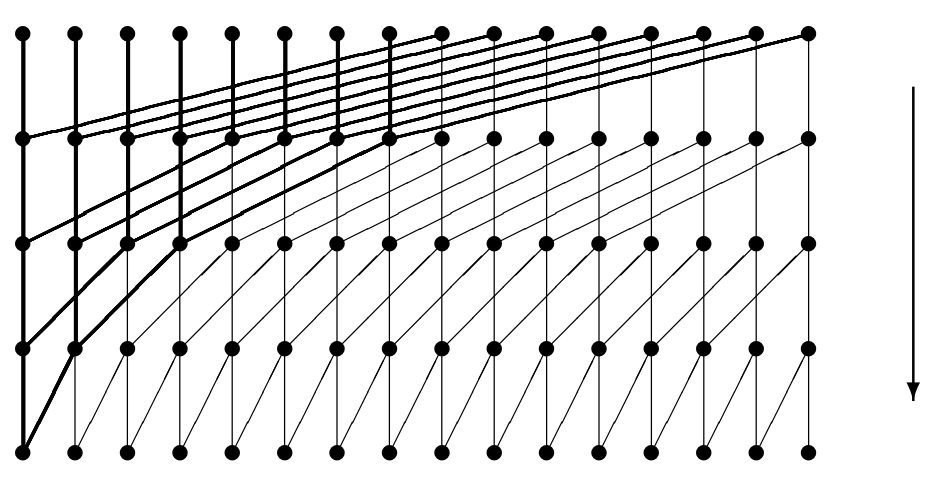

In [21]:
%%writefile reduction.cu

////////////////////////////////////////////////////////////////////////
//
// Practical 4 -- initial code for shared memory reduction for
//                a single block which is a power of two in size
//
////////////////////////////////////////////////////////////////////////

#include <stdlib.h>
#include <stdio.h>
#include <string.h>
#include <math.h>
#include <float.h>

#include <helper_cuda.h>

////////////////////////////////////////////////////////////////////////
// CPU routine
////////////////////////////////////////////////////////////////////////

float reduction_gold(float* idata, int len)
{
  float sum = 0.0f;
  for(int i=0; i<len; i++) sum += idata[i];

  return sum;
}

////////////////////////////////////////////////////////////////////////
// GPU routine
////////////////////////////////////////////////////////////////////////

__global__ void reduction(float *g_odata, float *g_idata)
{
    // dynamically allocated shared memory

    extern  __shared__  float temp[];

    int tid = threadIdx.x;

    // first, each thread loads data into shared memory

    temp[tid] = g_idata[tid];

    // next, we perform binary tree reduction

    for (int d=blockDim.x/2; d>0; d=d/2) {
      __syncthreads();  // ensure previous step completed
      if (tid<d)  temp[tid] += temp[tid+d];
    }

    // finally, first thread puts result into global memory

    if (tid==0) g_odata[0] = temp[0];
}


////////////////////////////////////////////////////////////////////////
// Program main
////////////////////////////////////////////////////////////////////////

int main( int argc, const char** argv)
{
  int num_blocks, num_threads, num_elements, mem_size, shared_mem_size;

  float *h_data, *d_idata, *d_odata;

  // initialise card

  findCudaDevice(argc, argv);

  num_blocks   = 1;  // start with only 1 thread block
  num_threads  = 512;
  num_elements = num_blocks*num_threads;
  mem_size     = sizeof(float) * num_elements;

  // allocate host memory to store the input data
  // and initialize to integer values between 0 and 10
  printf("Initial code for shared memory reduction for a single block which is a power of two in size. \n");
  h_data = (float*) malloc(mem_size);

  for(int i = 0; i < num_elements; i++)
    h_data[i] = floorf(10.0f*(rand()/(float)RAND_MAX));

  // compute reference solution

  float sum = reduction_gold(h_data, num_elements);

  // allocate device mProblem: For continuous features, there may be very few or no samples exactly at xjxjemory input and output arrays

  checkCudaErrors( cudaMalloc((void**)&d_idata, mem_size) );
  checkCudaErrors( cudaMalloc((void**)&d_odata, sizeof(float)) );

  // copy host memory to device input array

  checkCudaErrors( cudaMemcpy(d_idata, h_data, mem_size,
                              cudaMemcpyHostToDevice) );

  // execute the kernel

  shared_mem_size = sizeof(float) * num_threads;
  reduction<<<num_blocks,num_threads,shared_mem_size>>>(d_odata,d_idata);
  getLastCudaError("reduction kernel execution failed");

  // copy result from device to host

  checkCudaErrors( cudaMemcpy(h_data, d_odata, sizeof(float),
                              cudaMemcpyDeviceToHost) );

  // check results

  printf("reduction error = %f\n",h_data[0]-sum);

  // cleanup memory

  free(h_data);
  checkCudaErrors( cudaFree(d_idata) );
  checkCudaErrors( cudaFree(d_odata) );

  // CUDA exit -- needed to flush printf write buffer

  cudaDeviceReset();
}


Overwriting reduction.cu


In [22]:
!nvcc reduction.cu -o reduction -I. -lineinfo -arch=sm_70 --ptxas-options=-v --use_fast_math -lcudart

ptxas info    : 0 bytes gmem
ptxas info    : Compiling entry function '_Z9reductionPfS_' for 'sm_70'
ptxas info    : Function properties for _Z9reductionPfS_
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 10 registers, 368 bytes cmem[0]


In [23]:
!./reduction

GPU Device 0: "Turing" with compute capability 7.5

Initial code for shared memory reduction for a single block which is a power of two in size. 
reduction error = 0.000000


**Output:**
GPU Device 0: "Turing" with compute capability 7.5

Initial code for shared memory reduction for a single block which is a power of two in size.

reduction error = 0.000000

By comparing the GPU result with a reference sum calculated on the CPU, and displaying the difference between the two values, we obtain an error of 0. That shows the result is correct.


Each thread processes one input element, and a synchronized binary tree reduction in shared memory ensures that all elements are summed exactly once. In fact with the loop:
````markdown
for (int d = blockDim.x/2; d > 0; d /= 2)
````


We perform a tree-based reduction in shared memory by repeatedly halving the number of active threads (512 → 256 → 128 → …) until a single accumulated sum remains in `temp[0]`.

The call to `__syncthreads()`make sure previous
operations have completed as seeing in course.

Finally, **thread 0** writes the reduced sum from shared memory to global memory.



# Question 5

Let's extend it to handle the general case by finding the largest power of 2 less than
blockSize, and adding the elements beyond that point to the corresponding
first set of elements of that size

In [24]:
%%writefile reduction_generale_case.cu

////////////////////////////////////////////////////////////////////////
// Code for shared memory reduction for a single block (general case)
// by finding the largest power of 2 less than or equal to the block size,
// and adding the elements beyond that point to the corresponding
// first set of elements of that size.
////////////////////////////////////////////////////////////////////////

#include <stdlib.h>
#include <stdio.h>
#include <string.h>
#include <math.h>
#include <float.h>

#include <helper_cuda.h>

////////////////////////////////////////////////////////////////////////
// CPU routine
////////////////////////////////////////////////////////////////////////

float reduction_gold(float* idata, int len)
{
  float sum = 0.0f;
  for(int i=0; i<len; i++) sum += idata[i];

  return sum;
}

////////////////////////////////////////////////////////////////////////
// GPU routine
////////////////////////////////////////////////////////////////////////

__global__ void reduction(float *g_odata, float *g_idata)
{
    // dynamically allocated shared memory

    extern  __shared__  float temp[];

    int tid = threadIdx.x;
    int n   = blockDim.x;

    // first, each thread loads data into shared memory

    temp[tid] = g_idata[tid];
    //__syncthreads();

    // find largest power of 2 <= n
    int m;
    for (m = 1; m < n; m = 2 * m) {}
    m = m / 2;

    // add extra elements to first m elements
    if (tid < n - m) {
        temp[tid] += temp[tid + m];
    }
   // __syncthreads();

    // next, we perform binary tree reduction

    for (int d=m/2; d>0; d=d/2) {
      __syncthreads();  // ensure previous step completed
      if (tid<d)  temp[tid] += temp[tid+d];
    }

    // finally, first thread puts result into global memory

    if (tid==0) g_odata[0] = temp[0];
}


////////////////////////////////////////////////////////////////////////
// Program main
////////////////////////////////////////////////////////////////////////

int main( int argc, const char** argv)
{ printf("Shared-memory reduction for a single block that supports any block size by converting it to a power-of-two reduction. \n");
  int num_blocks, num_threads, num_elements, mem_size, shared_mem_size;

  float *h_data, *d_idata, *d_odata;

  // initialise card

  findCudaDevice(argc, argv);

  num_blocks   = 1;  // start with only 1 thread block
  num_threads  = 512;
  num_elements = num_blocks*num_threads;
  mem_size     = sizeof(float) * num_elements;
  // allocate host memory to store the input data
  // and initialize to integer values between 0 and 10
  h_data = (float*) malloc(mem_size);
  for(int i = 0; i < num_elements; i++)
    h_data[i] = floorf(10.0f*(rand()/(float)RAND_MAX));

  // compute reference solution

  float sum = reduction_gold(h_data, num_elements);

  // allocate device mProblem: For continuous features, there may be very few or no samples exactly at xjxjemory input and output arrays

  checkCudaErrors( cudaMalloc((void**)&d_idata, mem_size) );
  checkCudaErrors( cudaMalloc((void**)&d_odata, sizeof(float)) );

  // copy host memory to device input array

  checkCudaErrors( cudaMemcpy(d_idata, h_data, mem_size,
                              cudaMemcpyHostToDevice) );

  // execute the kernel

  shared_mem_size = sizeof(float) * num_threads;
  reduction<<<num_blocks,num_threads,shared_mem_size>>>(d_odata,d_idata);
  getLastCudaError("reduction kernel execution failed");

  // copy result from device to host

  checkCudaErrors( cudaMemcpy(h_data, d_odata, sizeof(float),
                              cudaMemcpyDeviceToHost) );

  // check results

  printf("reduction error = %f\n",h_data[0]-sum);

  // cleanup memory

  free(h_data);
  checkCudaErrors( cudaFree(d_idata) );
  checkCudaErrors( cudaFree(d_odata) );

  // CUDA exit -- needed to flush printf write buffer

  cudaDeviceReset();
}


Overwriting reduction_generale_case.cu


In [25]:
!nvcc reduction_generale_case.cu -o reduction_generale_case -I. -lineinfo -arch=sm_70 --ptxas-options=-v --use_fast_math -lcudart

ptxas info    : 0 bytes gmem
ptxas info    : Compiling entry function '_Z9reductionPfS_' for 'sm_70'
ptxas info    : Function properties for _Z9reductionPfS_
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 10 registers, 368 bytes cmem[0]


In [26]:
!./reduction_generale_case

Shared-memory reduction for a single block that supports any block size by converting it to a power-of-two reduction. 
GPU Device 0: "Turing" with compute capability 7.5

reduction error = 0.000000


**Output:**

Shared-memory reduction for a single block that supports any block size by converting it to a power-of-two reduction.

GPU Device 0: "Turing" with compute capability 7.5

reduction error = 0.000000

We implemented a shared-memory reduction that works for any block size.

*   First, each thread loads one input value into shared memory. Then we find the largest power of two that is smaller than or equal to the block size. We did with:
````markdown
int m;
for (m = 1; m < n; m = 2 * m) {}
    m = m / 2;
````

 If there are extra values, we add them to the first values so that the total number becomes a power of two.
 That we do with:
 ````markdown
 if (tid < n - m) {
        temp[tid] += temp[tid + m];
    }
 ````
*   After that, we use a normal parallel reduction to sum all values. The final result is written to global memory and checked by comparing it with a sum calculated on the CPU.

# Question 6

Let's modify the code to perform reduction using 1000 blocks each with 512
threads, with each block working with a different section of an input array of
size 512000.

There are two ways in which the partial sums from
each block can be summed.Here, we use the method in which each block stores its partial sum in a separate element of the output array, and the final reduction is performed on the host.

In [27]:
%%writefile reduction_100blocks.cu

////////////////////////////////////////////////////////////////////////
//
// Practical 4 -- code to perform reduction using 1000 blocks each with 512
// threads
//
////////////////////////////////////////////////////////////////////////

#include <stdlib.h>
#include <stdio.h>
#include <string.h>
#include <math.h>
#include <float.h>

#include <helper_cuda.h>

////////////////////////////////////////////////////////////////////////
// CPU routine
////////////////////////////////////////////////////////////////////////

float reduction_gold(float* idata, int len)
{
  float sum = 0.0f;
  for(int i=0; i<len; i++) sum += idata[i];

  return sum;
}

////////////////////////////////////////////////////////////////////////
// GPU routine
////////////////////////////////////////////////////////////////////////

__global__ void reduction(float *g_odata, float *g_idata,int n_per_block)
{
    // dynamically allocated shared memory

    extern  __shared__  float temp[];

    int tid = threadIdx.x;

    // first, each thread loads data into shared memory

    temp[tid] = g_idata[ blockIdx.x * n_per_block + tid];

    // next, we perform binary tree reduction

    for (int d=blockDim.x/2; d>0; d=d/2) {
      __syncthreads();  // ensure previous step completed
      if (tid<d)  temp[tid] += temp[tid+d];
    }

    // finally, first thread puts result into global memory

    if (tid==0) g_odata[blockIdx.x] = temp[0];
}


////////////////////////////////////////////////////////////////////////
// Program main
////////////////////////////////////////////////////////////////////////

int main( int argc, const char** argv)
{  printf("Shared-memory reduction using 1000 blocks each with 512 threads \n");
  int num_blocks, num_threads, num_elements, mem_size;
  float *h_data, *d_idata;
  float *d_partial_sums;

  // initialise card

  findCudaDevice(argc, argv);

  num_blocks   = 100;  //  100  thread block
  num_threads  = 512;
  num_elements = num_blocks*num_threads;
  mem_size     = sizeof(float) * num_elements;

  // allocate host memory to store the input data
  // and initialize to integer values between 0 and 10

  h_data = (float*) malloc(mem_size);

  for(int i = 0; i < num_elements; i++)
    h_data[i] = floorf(10.0f*(rand()/(float)RAND_MAX));

  // compute reference solution

  float sum = reduction_gold(h_data, num_elements);

  // allocate device mProblem: For continuous features, there may be very few or no samples exactly at xjxjemory input and output arrays

  checkCudaErrors( cudaMalloc((void**)&d_idata, mem_size) );
  checkCudaErrors(cudaMalloc((void**)&d_partial_sums, sizeof(float) * num_blocks));
  int shared_mem_size = sizeof(float) * num_threads;

  // copy host memory to device input array

  checkCudaErrors( cudaMemcpy(d_idata, h_data, mem_size,
                              cudaMemcpyHostToDevice) );

  // execute the kernel

  reduction<<<num_blocks, num_threads, shared_mem_size>>>(d_partial_sums, d_idata, num_threads);
  cudaDeviceSynchronize();  // to understand
  getLastCudaError("reduction kernel execution failed");

  // copy result from device to host

  float *h_partial_sums = (float*) malloc(sizeof(float) * num_blocks);
  checkCudaErrors(cudaMemcpy(h_partial_sums, d_partial_sums, sizeof(float) * num_blocks, cudaMemcpyDeviceToHost));
  float gpu_sum = 0.0f;
  for (int i = 0; i < num_blocks; i++) gpu_sum += h_partial_sums[i];
  // check results
  printf("CPU sum = %f, GPU sum = %f, error = %f\n", sum, gpu_sum, gpu_sum - sum);

  // cleanup memory

  free(h_partial_sums);
  checkCudaErrors(cudaFree(d_partial_sums));
  checkCudaErrors(cudaFree(d_idata));

  // CUDA exit -- needed to flush printf write buffer

  cudaDeviceReset();
}


Overwriting reduction_100blocks.cu


In [28]:
!nvcc reduction_100blocks.cu -o reduction_100blocks -I. -lineinfo -arch=sm_70 --ptxas-options=-v --use_fast_math -lcudart

ptxas info    : 0 bytes gmem
ptxas info    : Compiling entry function '_Z9reductionPfS_i' for 'sm_70'
ptxas info    : Function properties for _Z9reductionPfS_i
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 10 registers, 372 bytes cmem[0]


In [29]:
!./reduction_100blocks

Shared-memory reduction using 1000 blocks each with 512 threads 
GPU Device 0: "Turing" with compute capability 7.5

CPU sum = 229520.000000, GPU sum = 229520.000000, error = 0.000000


**Output :**
Shared-memory reduction using 1000 blocks each with 512 threads

GPU Device 0: "Turing" with compute capability 7.5

CPU sum = 229520.000000, GPU sum = 229520.000000, error = 0.000000

The input array is divided into parts, and each GPU block works on one part. Inside each block, every thread loads one value into shared memory and the block performs a parallel reduction to compute a partial sum.

Each block then stores its partial sum in a separate position in the output array. These partial sums are copied back to the CPU and added together to produce the final sum. The result is checked by comparing the GPU result with a sum computed on the CPU.

# Question 7

Let's modify the block-level reduction to use shuffle instructions as described in
Lecture 4.

In [30]:
%%writefile reduction_shuffle.cu

////////////////////////////////////////////////////////////////////////
//
// Practical 4 -- code for shared memory reduction for
//                100 blocks whith shuffle
//
////////////////////////////////////////////////////////////////////////

#include <stdlib.h>
#include <stdio.h>
#include <string.h>
#include <math.h>
#include <float.h>

#include <helper_cuda.h>

////////////////////////////////////////////////////////////////////////
// CPU routine
////////////////////////////////////////////////////////////////////////

float reduction_gold(float* idata, int len)
{
  float sum = 0.0f;
  for(int i=0; i<len; i++) sum += idata[i];

  return sum;
}

////////////////////////////////////////////////////////////////////////
// GPU routine
////////////////////////////////////////////////////////////////////////
__global__ void reduction(float *g_odata, const float *g_idata, int n_per_block)
{
    int tid = threadIdx.x;
    int idx = blockIdx.x * n_per_block + tid;

    float val = g_idata[idx];

    // Warp-level reduction using shuffle
    for (int offset = 16; offset > 0; offset /= 2)
        val += __shfl_down_sync(0xffffffff, val, offset);

    // Store each warp's sum into shared memory
    __shared__ float warp_sums[32];  // max 32 warps per block

    int warp_id = tid / 32;  // warp index in block
    int lane    = tid % 32;  // thread index in warp

    if (lane == 0)
        warp_sums[warp_id] = val;

    __syncthreads();

    // First warp reduces the warp sums
    if (warp_id == 0)
    {
        // Load warp sums into first warp threads
        val = (tid < blockDim.x / 32) ? warp_sums[lane] : 0.0f;

        // Reduce warp sums within first warp
        for (int offset = 16; offset > 0; offset /= 2)
            val += __shfl_down_sync(0xffffffff, val, offset);

        // Thread 0 writes the final block sum
        if (tid == 0)
            g_odata[blockIdx.x] = val;
    }
}

////////////////////////////////////////////////////////////////////////
// Program main
////////////////////////////////////////////////////////////////////////

int main( int argc, const char** argv)
{ printf(" Shuffle reduction using 1000 blocks each with 512 threads \n");
  int num_blocks, num_threads, num_elements, mem_size;
  float *h_data, *d_idata;
  float *d_partial_sums;

  // initialise card

  findCudaDevice(argc, argv);

  num_blocks   = 100;  //  100  thread block
  num_threads  = 512;
  num_elements = num_blocks*num_threads;
  mem_size     = sizeof(float) * num_elements;

  // allocate host memory to store the input data
  // and initialize to integer values between 0 and 10

  h_data = (float*) malloc(mem_size);

  for(int i = 0; i < num_elements; i++)
    h_data[i] = floorf(10.0f*(rand()/(float)RAND_MAX));

  // compute reference solution

  float sum = reduction_gold(h_data, num_elements);

  // allocate device mProblem: For continuous features, there may be very few or no samples exactly at xjxjemory input and output arrays

  checkCudaErrors( cudaMalloc((void**)&d_idata, mem_size) );
  checkCudaErrors(cudaMalloc((void**)&d_partial_sums, sizeof(float) * num_blocks));
  int shared_mem_size = sizeof(float) * num_threads;

  // copy host memory to device input array

  checkCudaErrors( cudaMemcpy(d_idata, h_data, mem_size,
                              cudaMemcpyHostToDevice) );

  // execute the kernel

  reduction<<<num_blocks, num_threads, shared_mem_size>>>(d_partial_sums, d_idata, num_threads);
  cudaDeviceSynchronize();  // to understand
  getLastCudaError("reduction kernel execution failed");

  // copy result from device to host

  float *h_partial_sums = (float*) malloc(sizeof(float) * num_blocks);
  checkCudaErrors(cudaMemcpy(h_partial_sums, d_partial_sums, sizeof(float) * num_blocks, cudaMemcpyDeviceToHost));
  float gpu_sum = 0.0f;
  for (int i = 0; i < num_blocks; i++) gpu_sum += h_partial_sums[i];
  // check results
  printf("CPU sum = %f, GPU sum = %f, error = %f\n", sum, gpu_sum, gpu_sum - sum);

  // cleanup memory

  free(h_partial_sums);
  checkCudaErrors(cudaFree(d_partial_sums));
  checkCudaErrors(cudaFree(d_idata));

  // CUDA exit -- needed to flush printf write buffer

  cudaDeviceReset();
}


Overwriting reduction_shuffle.cu


In [31]:
!nvcc reduction_shuffle.cu -o reduction_shuffle -I. -lineinfo -arch=sm_70 --ptxas-options=-v --use_fast_math -lcudart

ptxas info    : 0 bytes gmem
ptxas info    : Compiling entry function '_Z9reductionPfPKfi' for 'sm_70'
ptxas info    : Function properties for _Z9reductionPfPKfi
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 14 registers, 128 bytes smem, 372 bytes cmem[0]


In [32]:
!./reduction_shuffle

 Shuffle reduction using 1000 blocks each with 512 threads 
GPU Device 0: "Turing" with compute capability 7.5

CPU sum = 229520.000000, GPU sum = 229520.000000, error = 0.000000


**Output**
Shuffle reduction using 1000 blocks each with 512 threads
GPU Device 0: "Turing" with compute capability 7.5

CPU sum = 229520.000000, GPU sum = 229520.000000, error = 0.000000

Here, we just use shuffle instructions as described in
Lecture 4 to the reduction.



In [ ]:
from google.colab import runtime
runtime.unassign()